# K-means on synthetic data
## Step 1 - generating a synthetic dataset

## Synthetic data

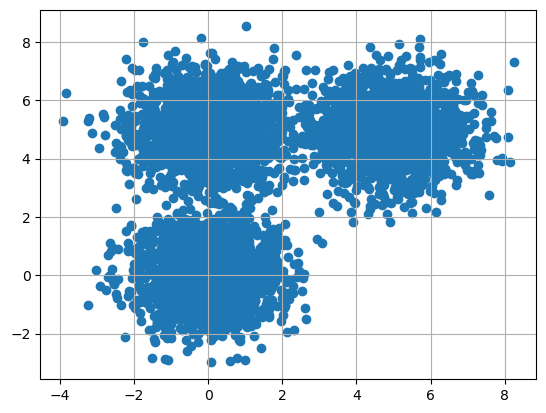

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(42)

n = 5000

# cluster sizes
n1 = n2 = n3 = n // 3

# define means manually
mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

# generate clusters
c1 = np.random.randn(n1, 2) + mean1
c2 = np.random.randn(n2, 2) + mean2
c3 = np.random.randn(n3, 2) + mean3

X_synth = np.vstack((c1, c2, c3))

plt.scatter(X_synth[:, 0], X_synth[:, 1])
plt.grid(True)
plt.show()

## Real world data - MNIST dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version = 1)

X = mnist.data.to_numpy()
X = X / 255.0 #normalizing the data
y = mnist.target.astype(int).to_numpy()

#subsetting mnist to work with a more manageable size

subset_size = 5000
indices = np.random.choice(X.shape[0], subset_size, replace=False)

X_subset = X[indices]
y_subset = y[indices]
X = X_subset
y = y_subset

print(X.shape)
print(y.shape)

(5000, 784)
(5000,)


## kmeans function

In [3]:
# helper functions

def random_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def get_labels(X, centroids):
    distances = []

    for centroid in centroids:
        dist = np.sqrt(np.sum((X - centroid) ** 2, axis=1))
        distances.append(dist)

    distances = np.array(distances).T

    return np.argmin(distances, axis=1)

def new_centroids(X, labels, k):
    centroids = []

    for i in range(k):
        points = X[labels == i]

        if len(points) == 0:
            centroid = X[np.random.randint(0, X.shape[0])]
        else:
            centroid = points.mean(axis=0)

        centroids.append(centroid)

    return np.array(centroids)

#kmeans final function

def kmeans(X, k, max_rounds=100):

    centroids = random_centroids(X, k)

    for iteration in range(max_rounds):

        old_centroids = centroids.copy()

        labels = get_labels(X, centroids)

        centroids = new_centroids(X, labels, k)

        if np.allclose(centroids, old_centroids):
            break

    return labels, centroids

## Example of kmeans results

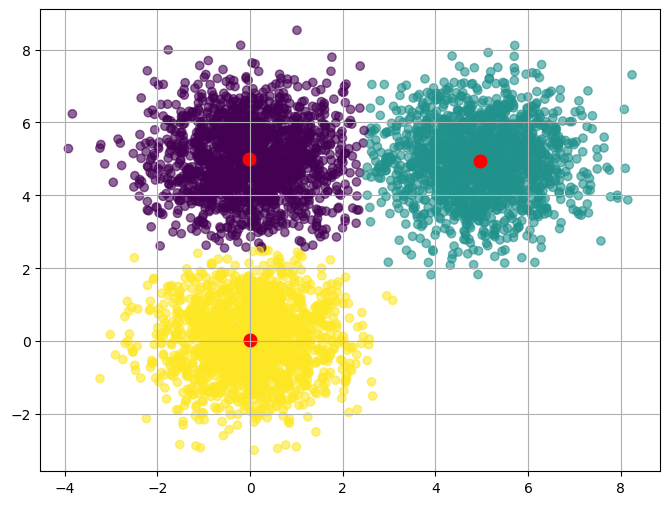

In [4]:
#Synthetic data example - visualizing full clusters with centroids

labels_synth, centroids_synth = kmeans(X_synth, 3)

plt.figure(figsize=(8, 6))

# plot data points
plt.scatter(
    X_synth[:, 0],
    X_synth[:, 1],
    c=labels_synth,
    alpha=0.6
)

# plot centroids
plt.scatter(
    centroids_synth[:, 0],
    centroids_synth[:, 1],
    color='red',
    marker='.',
    s=200,
    linewidths=3
)

plt.grid(True)
plt.show()

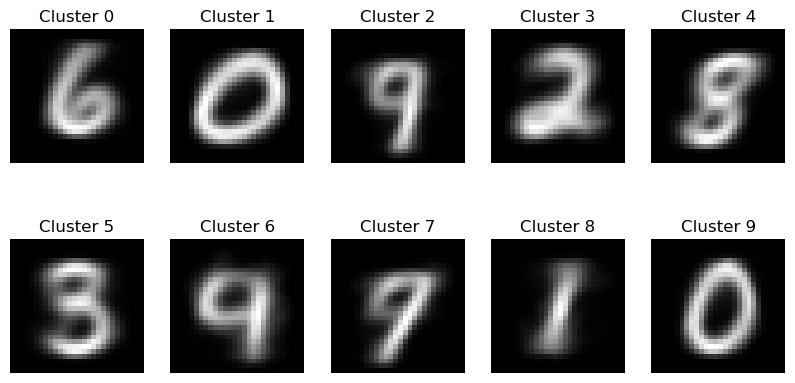

In [5]:
#Real data exaple - visualizing the selected centroids for each cluster

labels, centroids = kmeans(X, 10)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(centroids[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')

plt.show()

## Calculating inertia

In [6]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)
    
    return inertia

In [7]:
inertia = compute_inertia(X, labels, centroids)
inertia_synth = compute_inertia(X_synth, labels_synth, centroids_synth)
print(inertia)
print(inertia_synth)

197443.3381984093
9885.09885840983


## Running repearted trials to calculate variance in results

In [8]:
def kmeans_trials(X, k, n_trials=20):
    inertias = []
    
    for i in range(n_trials):
        labels, centroids = kmeans(X,k)
        inertia = compute_inertia(X, labels, centroids)
        inertias.append(inertia)

    return inertias 

In [9]:
# running multiple (100) trials on kmeans - synthetic data

inertias_synth = kmeans_trials(X_synth, 3, 100)

# running multiple trials on kmeans - real data

inertias_real = kmeans_trials(X, 10, 50)

#visualizing variance 

print(np.mean(inertias_synth))
print(np.mean(inertias_real))

9885.098858409827
197065.91053527087


Synthetic:
Mean: 9885.098858409827
Std: 3.637978807091713e-12
Var: 1.3234889800848443e-23

MNIST:
Mean: 197065.91053527087
Std: 696.8962391146513
Var: 485664.36809214525


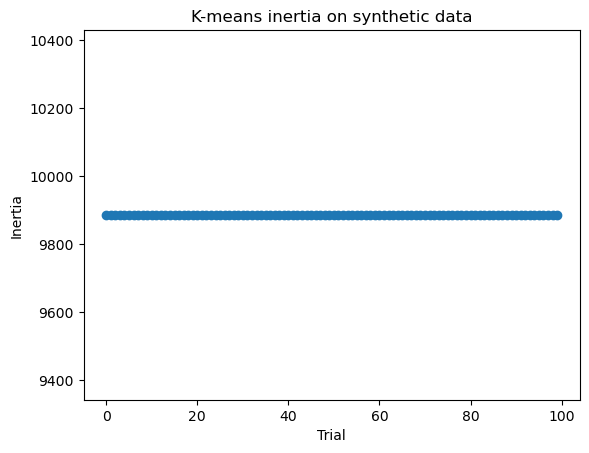

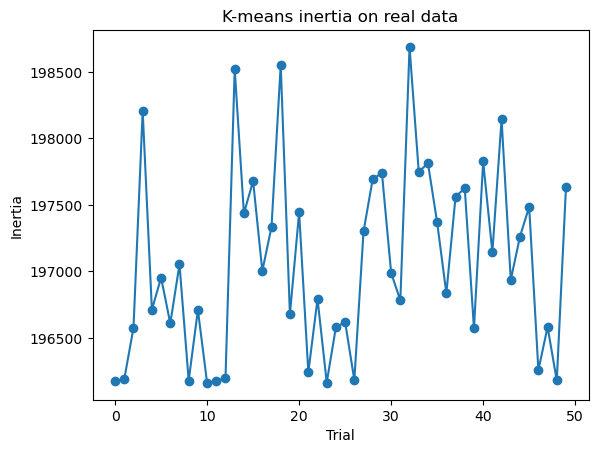

In [24]:
print("Synthetic:")
print("Mean:", np.mean(inertias_synth))
print("Std:", np.std(inertias_synth))
print("Var:", np.var(inertias_synth))

print("\nMNIST:")
print("Mean:", np.mean(inertias_real))
print("Std:", np.std(inertias_real))
print("Var:", np.var(inertias_real))

plt.plot(inertias_synth, marker='o')
plt.xlabel("Trial")
plt.ylabel("Inertia")
plt.title("K-means inertia on synthetic data")

plt.show()

plt.plot(inertias_real, marker='o')
plt.xlabel("Trial")
plt.ylabel("Inertia")
plt.title("K-means inertia on real data")

plt.show()


Notice how the variance of results for the synthetic dataset is basically non existent - that's because the dataset is composed of three groups of well separated points, that kmeans has no issue separating into clusters. This leads to extremely similar results for each iteration